In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler ,LabelEncoder , OrdinalEncoder



In [ ]:
df = pd.read_csv('/content/Telco_Churn_Project_Dataset.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLV_proxy,AvgChargesPerYear,HighValueCustomer,ActiveServiceCount,TenureGroup,PriceSensitivity
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,29.85,358.200000,0,1,0-1yr,14.9250
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,1936.30,666.882353,0,3,2-4yr,14.2375
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,NaN,Yes,...,Mailed check,53.85,108.15,Yes,107.70,648.900000,0,3,0-1yr,13.4625
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,1903.50,490.866667,0,3,2-4yr,10.5750
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,141.40,909.900000,1,1,0-1yr,35.3500


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'CLV_proxy',
       'AvgChargesPerYear', 'HighValueCustomer', 'ActiveServiceCount',
       'TenureGroup', 'PriceSensitivity'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   gender              7043 non-null   object 
 2   SeniorCitizen       7043 non-null   int64  
 3   Partner             7043 non-null   object 
 4   Dependents          7043 non-null   object 
 5   tenure              6399 non-null   float64
 6   PhoneService        7043 non-null   object 
 7   MultipleLines       7043 non-null   object 
 8   InternetService     6617 non-null   object 
 9   OnlineSecurity      7043 non-null   object 
 10  OnlineBackup        7043 non-null   object 
 11  DeviceProtection    7043 non-null   object 
 12  TechSupport         7043 non-null   object 
 13  StreamingTV         7043 non-null   object 
 14  StreamingMovies     7043 non-null   object 
 15  Contract            7043 non-null   object 
 16  Paperl

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CLV_proxy,AvgChargesPerYear,HighValueCustomer,ActiveServiceCount,PriceSensitivity
count,7043.000000,6399.000000,6628.000000,6548.000000,6014.000000,5958.000000,7043.000000,7043.000000,6628.000000
mean,0.162147,32.171277,64.647239,2285.964676,2249.038884,773.839094,0.470538,3.362914,15.383388
std,0.368612,24.584857,30.104575,2266.179408,2254.061293,361.613577,0.499167,2.062031,5.966817
min,0.000000,0.000000,18.250000,18.800000,0.000000,165.300000,0.000000,0.000000,7.650000
25%,0.000000,8.000000,35.337500,401.925000,381.175000,425.941622,0.000000,1.000000,10.325000
50%,0.000000,28.000000,70.275000,1406.775000,1361.675000,840.418093,0.000000,3.000000,13.950000
75%,0.000000,55.000000,89.850000,3808.850000,3735.300000,1078.963744,1.000000,5.000000,18.070000
max,1.000000,72.000000,118.750000,8684.800000,8550.000000,1456.800000,1.000000,8.000000,36.125000


In [ ]:
drop_cols = [
    'customerID',
    'CLV_proxy',
    'AvgChargesPerYear'
]

df.drop(columns=drop_cols, inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns


print(num_cols)

print(cat_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'HighValueCustomer', 'ActiveServiceCount', 'PriceSensitivity'],
      dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn', 'TenureGroup'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,644
PhoneService,0
MultipleLines,0
InternetService,426
OnlineSecurity,0
OnlineBackup,0


In [ ]:
# NaN values columns = tenure , InternetService , PaymentMethod , MonthlyCharges ,TotalCharges ,CLV_proxy
#                       AvgChargesPerYear , TenureGroup	, PriceSensitivity .

# InternetService , PaymentMethod ,TenureGroup	. categorical columns fill by mode

In [ ]:
# Handle Missing Values (Categorical):-

df['InternetService'] = df['InternetService'].fillna(method='ffill')

df['PaymentMethod'] = df['PaymentMethod'].fillna(method='bfill')

df['TenureGroup'] = df['TenureGroup'].fillna(method='bfill')

/tmp/ipython-input-587737277.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['InternetService'] = df['InternetService'].fillna(method='ffill')
/tmp/ipython-input-587737277.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['PaymentMethod'] = df['PaymentMethod'].fillna(method='bfill')
/tmp/ipython-input-587737277.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['TenureGroup'] = df['TenureGroup'].fillna(method='bfill')


In [ ]:
# Handle Missing Values (Numerical):-

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-2982725430.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df['Churn']

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1,'No': 0})

df['Churn']

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [ ]:
# Check Outliers (IQR Method) :-

Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['MonthlyCharges'] >= lower) & (df['MonthlyCharges'] <= upper)]

df['MonthlyCharges']


,MonthlyCharges
0,29.85
1,56.95
2,53.85
3,42.30
4,70.70
...,...
7038,84.80
7039,103.20
7040,29.60
7041,74.40


In [ ]:
# Fix TotalCharges Data Type :-

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [ ]:
df = pd.get_dummies(
    df,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True
)


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,ActiveServiceCount,TenureGroup,PriceSensitivity,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,0,Yes,No,1.0,No,No phone service,No,Yes,No,...,1,0-1yr,14.9250,False,False,False,False,False,True,False
1,Male,0,No,No,34.0,Yes,No,Yes,No,Yes,...,3,2-4yr,14.2375,False,False,True,False,False,False,True
2,Male,0,No,No,2.0,Yes,No,Yes,Yes,No,...,3,0-1yr,13.4625,False,False,False,False,False,False,True
3,Male,0,No,No,45.0,No,No phone service,Yes,No,Yes,...,3,2-4yr,10.5750,False,False,True,False,False,False,False
4,Female,0,No,No,2.0,Yes,No,No,No,No,...,1,0-1yr,35.3500,True,False,False,False,False,True,False


In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


In [ ]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})


In [ ]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })


In [ ]:
df['MultipleLines'] = df['MultipleLines'].map({
    'Yes': 1,
    'No': 0,
    'No phone service': 0
})


In [ ]:
le = LabelEncoder()


df['TenureGroup'] = le.fit_transform(df['TenureGroup'])


In [ ]:

df.isnull().sum()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print(f"Linear Regression R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

Linear Regression R2 Score: 0.26
Mean Squared Error: 0.14


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Logistic Regression Accuracy: 0.80


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)


print(f"Decision Tree Accuracy: {tree_model.score(X_test, y_test):.2f}")

Decision Tree Accuracy: 0.79


In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Random Forest Accuracy: {rf_model.score(X_test, y_test):.2f}")

Random Forest Accuracy: 0.79


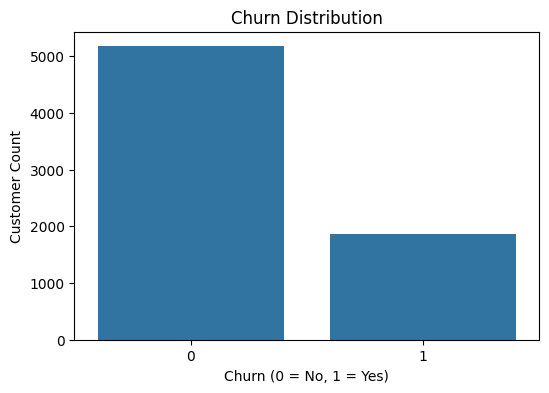

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Customer Count')
plt.show()


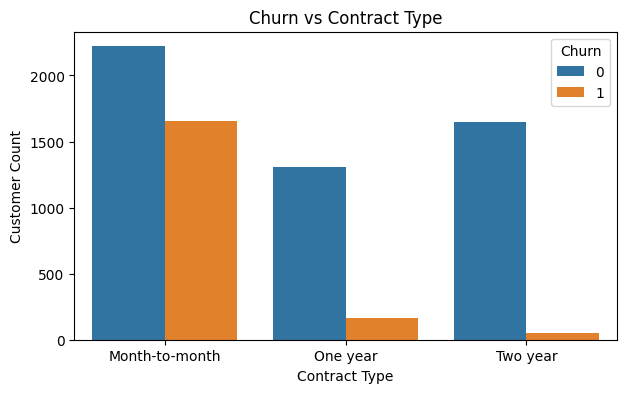

In [ ]:
contract_cols = [col for col in df.columns if col.startswith('Contract_')]

df_contract = df.copy()
df_contract['ContractType'] = 'Month-to-month'

for col in contract_cols:
    df_contract.loc[df_contract[col] == 1, 'ContractType'] = col.replace('Contract_', '')

plt.figure(figsize=(7,4))
sns.countplot(x='ContractType', hue='Churn', data=df_contract)
plt.title('Churn vs Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.legend(title='Churn')
plt.show()


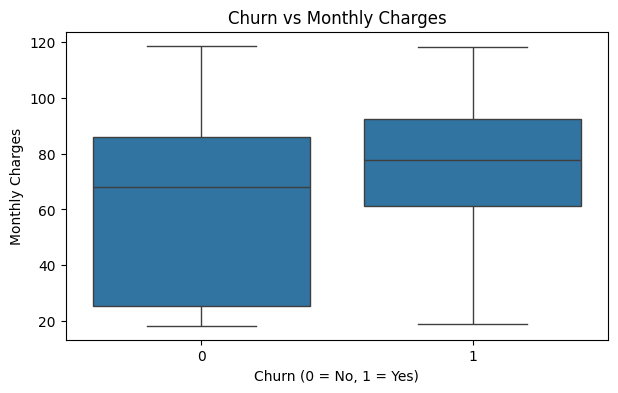

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Churn vs Monthly Charges')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')
plt.show()


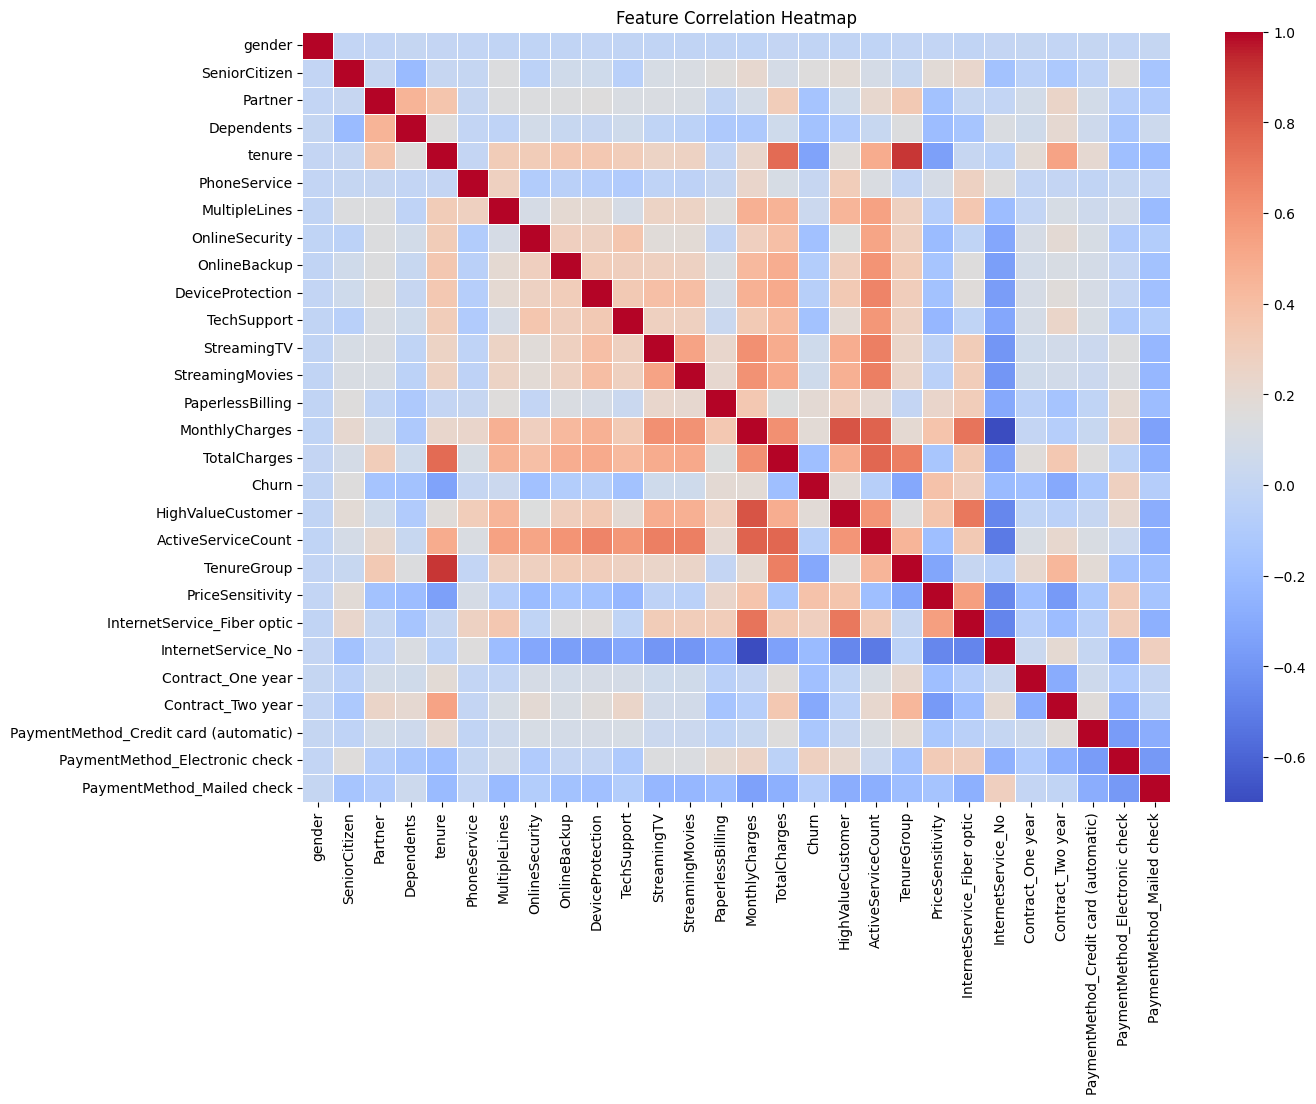

In [ ]:
plt.figure(figsize=(14,10))
corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')
plt.show()
